In [1]:
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, cohen_kappa_score, balanced_accuracy_score, matthews_corrcoef, f1_score
import matplotlib.pyplot as plt
import pandas as pd

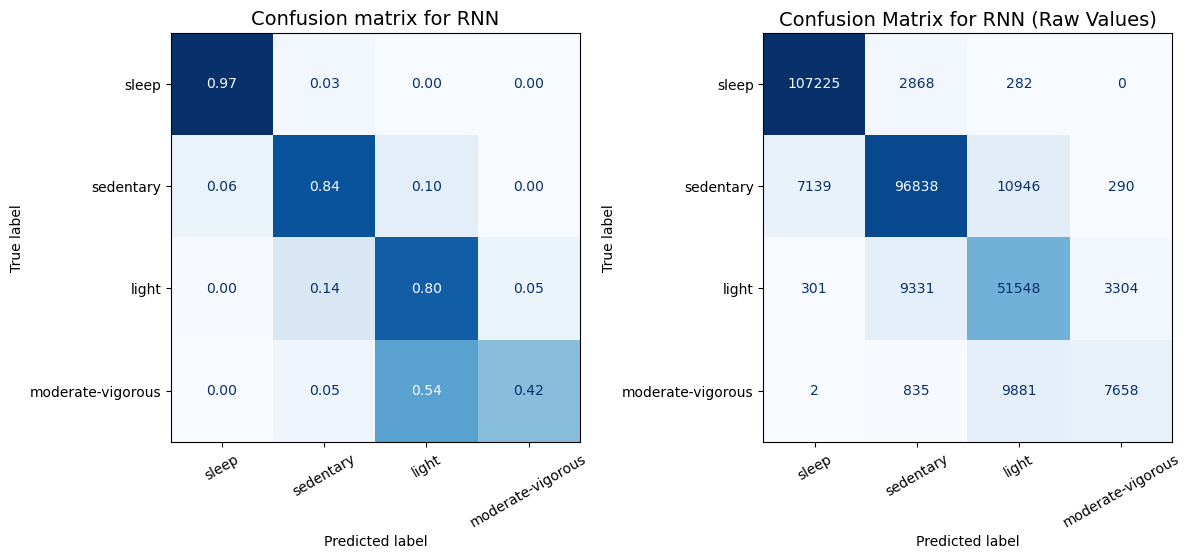

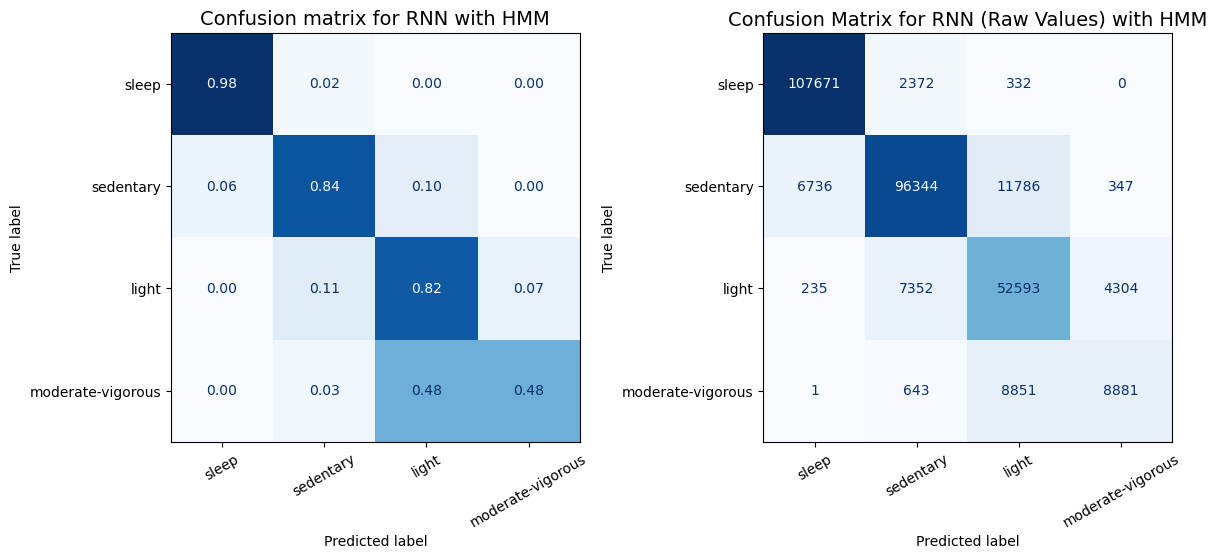

In [16]:
#RNN with no HMM
PAorder = ['sleep', 'sedentary','light','moderate-vigorous']

RNN_pred = np.load("final_pred_test.npz")
RNN_pred_hmm = np.load("final_pred_hmm.npz")

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions(  RNN_pred['true_labels'], RNN_pred['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for RNN', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( RNN_pred['true_labels'], RNN_pred['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for RNN (Raw Values)', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions(  RNN_pred_hmm['true_labels'], RNN_pred_hmm['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for RNN with HMM', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( RNN_pred_hmm['true_labels'], RNN_pred_hmm['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for RNN (Raw Values) with HMM', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

#### Now CNN

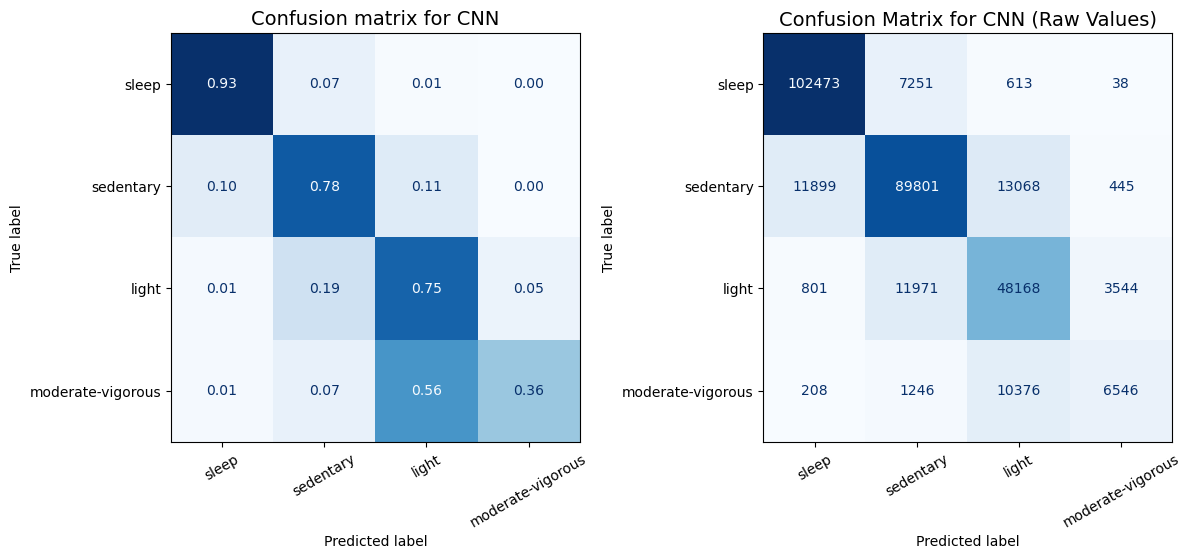

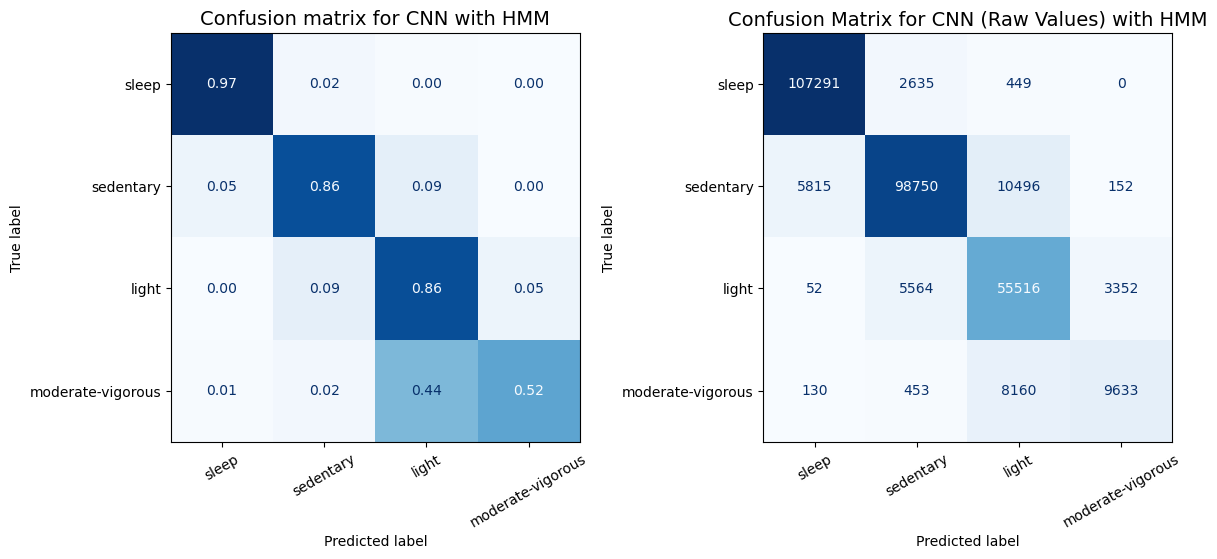

In [22]:
CNN = np.load("final_pred_CNN_test.npz")
CNN_HMM = np.load("final_pred_CNN_test_hmm.npz")

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( CNN['true_labels'], CNN['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for CNN', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions(  CNN['true_labels'], CNN['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues', values_format='d')
ax[1].set_title('Confusion Matrix for CNN (Raw Values)', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( CNN_HMM['true_labels'], CNN_HMM['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for CNN with HMM', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( CNN_HMM['true_labels'], CNN_HMM['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues', values_format = 'd')
ax[1].set_title('Confusion Matrix for CNN (Raw Values) with HMM', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [29]:
pred = pd.read_csv("final_pred_test_ds.csv")
# pred = pred.rename(columns = { 'hmm_preds':'model_preds'})
# pred

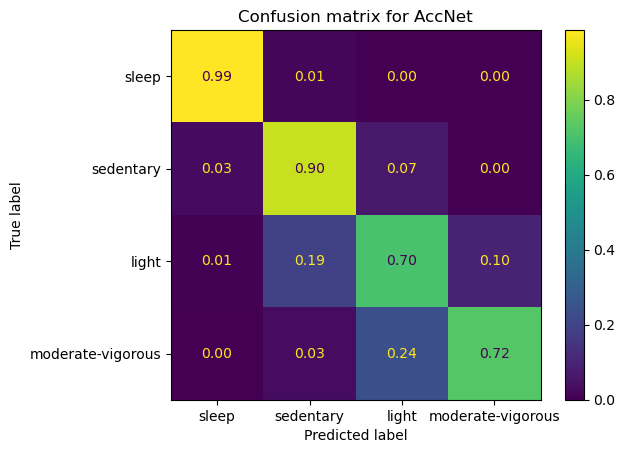

Metrics report for the AccNet: 

                   precision    recall  f1-score   support

            light       0.76      0.70      0.73     16539
moderate-vigorous       0.61      0.72      0.66      3850
        sedentary       0.91      0.90      0.91     41291
            sleep       0.97      0.99      0.98     36012

         accuracy                           0.89     97692
        macro avg       0.81      0.83      0.82     97692
     weighted avg       0.89      0.89      0.89     97692

 test/bacc: 0.829
  test/phi: 0.836
test/kappa: 0.836
test/f1: 0.819


In [30]:

ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

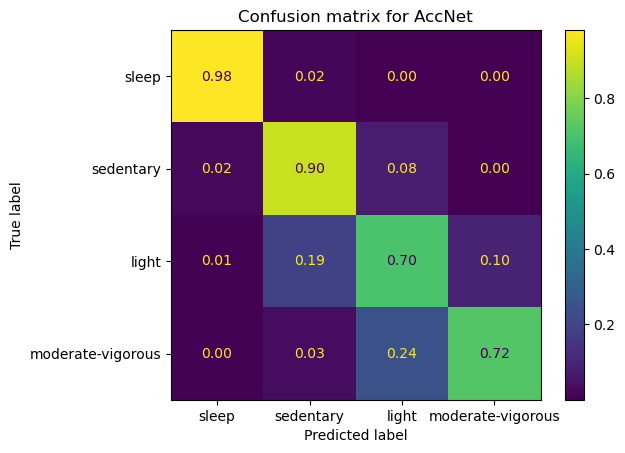

Metrics report for the AccNet: 

                   precision    recall  f1-score   support

            light       0.73      0.70      0.72     16539
moderate-vigorous       0.61      0.72      0.66      3850
        sedentary       0.90      0.90      0.90     41291
            sleep       0.97      0.98      0.98     36012

         accuracy                           0.89     97692
        macro avg       0.81      0.83      0.81     97692
     weighted avg       0.89      0.89      0.89     97692

 test/bacc: 0.825
  test/phi: 0.830
test/kappa: 0.830
test/f1: 0.814


In [31]:
# val
pred = pd.read_csv("final_pred_test.csv")
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

NameError: name 'PAorder' is not defined

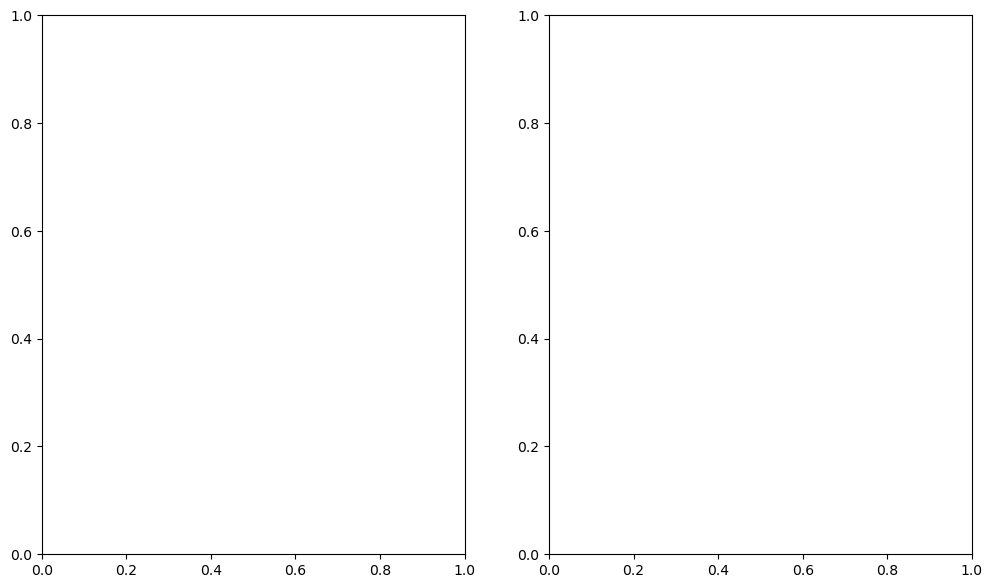

In [2]:
# Side by Side Normalised and true values for confusion matrices
pred = pd.read_csv("final_pred_test_test2_Best.csv")
fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for AccNet with \n 10Hz Sample Rate', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for AccNet (Raw Values) with \n 10Hz Sample Rate', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 10 Class problem

In [23]:
pred = pd.read_csv("final_pred_test_ten_hmm.csv").rename(columns = {"hmm_preds": "model_preds"})
pred.head(10)

,true_labels,model_preds
0,sleep,sleep
1,sleep,sleep
2,sleep,sleep
3,sleep,sleep
4,sleep,sleep
5,sleep,sleep
6,sleep,sleep
7,sleep,sleep
8,sleep,sleep
9,sleep,sleep


In [3]:
# Ordering 
HARorder = ['sleep', 'sitting','standing','household-chores','manual-work','walking','mixed-activity','vehicle','sports','bicycling']

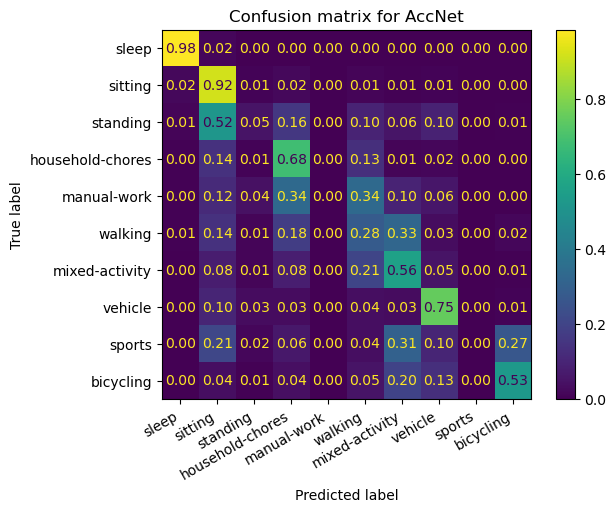

Metrics report for the AccNet: 



c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

       bicycling       0.55      0.53      0.54       753
household-chores       0.61      0.68      0.64      6752
     manual-work       0.00      0.00      0.00       636
  mixed-activity       0.39      0.56      0.46      3217
         sitting       0.88      0.92      0.90     37377
           sleep       0.97      0.98      0.98     36012
          sports       0.00      0.00      0.00       509
        standing       0.17      0.05      0.08      2775
         vehicle       0.70      0.75      0.73      3841
         walking       0.38      0.28      0.32      5825

        accuracy                           0.83     97697
       macro avg       0.46      0.48      0.47     97697
    weighted avg       0.81      0.83      0.82     97697

 test/bacc: 0.477
  test/phi: 0.760
test/kappa: 0.760
test/f1: 0.465


In [4]:
pred = pd.read_csv("final_pred_test_ten_w_ds.csv")
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=HARorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.xticks(rotation=30, ha = 'right')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

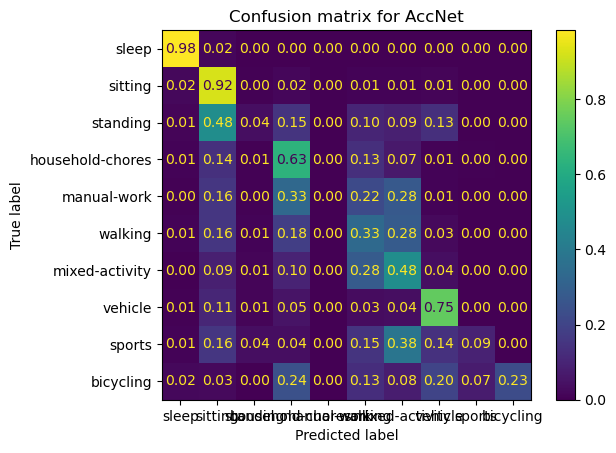

Metrics report for the AccNet: 



c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

       bicycling       0.98      0.23      0.37       753
household-chores       0.58      0.63      0.61      6752
     manual-work       0.00      0.00      0.00       636
  mixed-activity       0.32      0.48      0.38      3217
         sitting       0.88      0.92      0.90     37374
           sleep       0.97      0.98      0.98     36012
          sports       0.28      0.09      0.14       509
        standing       0.23      0.04      0.07      2774
         vehicle       0.68      0.75      0.71      3841
         walking       0.40      0.33      0.37      5824

        accuracy                           0.83     97692
       macro avg       0.53      0.45      0.45     97692
    weighted avg       0.81      0.83      0.82     97692

 test/bacc: 0.446
  test/phi: 0.755
test/kappa: 0.754
test/f1: 0.452


In [28]:
pred = pd.read_csv("final_pred_test_ten.csv")
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels = HARorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

## Participant demographic analysis ##

In [30]:
meta_data = pd.read_csv('data\capture24\metadata.csv')
metrics_pp = pd.read_csv("Participant_Metrics_Summary.csv")

In [31]:
#Gets just participants 101-151
meta_data_test = meta_data.iloc[-51:].drop(columns = ["pid"], axis = 1)
meta_data_test = meta_data_test.reset_index(drop=True)
master = pd.merge(metrics_pp, meta_data_test, left_index = True, right_index=True)

In [32]:
#find average BACC and F1 in...

#Male and gender
by_gender = master.groupby('sex')[["Balanced_Accuracy", "Macro_F1"]].mean()

#Age 
by_age = master.groupby('age')[["Balanced_Accuracy", "Macro_F1"]].mean()

both = master.groupby(['age', 'sex'])[["Balanced_Accuracy", "Macro_F1"]].mean()
print(by_gender)
print(by_age)
by_gender


     Balanced_Accuracy  Macro_F1
sex                             
F             0.797329  0.786420
M             0.764724  0.774803
       Balanced_Accuracy  Macro_F1
age                               
18-29           0.790176  0.787086
30-37           0.762637  0.774501
38-52           0.793710  0.779882
53+             0.797079  0.787772


,Balanced_Accuracy,Macro_F1
sex,,
F,0.797329,0.786420
M,0.764724,0.774803
